In [12]:
import os
from os.path import join
from glob import glob
import numpy as np
from datasets_ws import path_to_pil_img
import matplotlib.pyplot as plt
from os.path import join
import torchvision
from ipywidgets import interact, widgets, interactive, Layout
import ipywidgets
from glob import glob
import os
import cv2
import PIL.Image
import shutil
import time

from datasets_ws import BaseDataset
import torchvision.transforms as T
from torch.utils.data.dataset import Subset
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import matplotlib as mpl
from tqdm import tqdm
import torch

In [13]:
os.environ["CUDA_VISIBLE_DEVICES"]=str(6)

In [14]:
train_data='gsv'
method='crica'
dataset='amstertime'
lr=1e-7
num="8" 
patience=None
saved_path_log= f"../logs/{train_data}_{method}/logfile{train_data}_{method}_finetuned_on_{dataset}_{lr}_{num}.pth"
saved_path_model= f"../logs/best_model_{train_data}_{method}/{train_data}_{method}_finetuned_on_{dataset}_{lr}_{num}.pth"
# saved_path= "logs/gsv_crica/logfilegsv_crica_finetuned_on_nordland.pth1e-05"
logfile=torch.load(saved_path_log)
args=logfile['args']
original_model=True

In [15]:
method="crica"

if method=="boq":
    image_size=[322,322]
    descriptors_dimension = 12288

        
    model = torch.hub.load("amaralibey/bag-of-queries", "get_trained_boq", backbone_name="dinov2", output_dim=12288)
#     for param in model.backbone.named_parameters():
#         if param[1].requires_grad:
#             param[1].requires_grad=False

    
elif method == "crica":
    image_size=[224,224]
    descriptors_dimension = 10752
    model=torch.hub.load("Lu-Feng/CricaVPR", "trained_model")
    args.features_dim=descriptors_dimension
elif method == "salad":
    image_size=[322,322]
    descriptors_dimension=8448
    features_dim=descriptors_dimension
    model = torch.hub.load("serizba/salad", "dinov2_salad")
    
    
if not original_model:
    state_dict=torch.load(saved_path_model)["model_state_dict"]
    model.load_state_dict()

Using cache found in /home/osverburg/.cache/torch/hub/Lu-Feng_CricaVPR_main


In [16]:
import pickle as pk
amount_of_test_features=1400
use_queries=True
args.infer_batch_size=1
n_batches=int(amount_of_test_features//args.infer_batch_size)


In [11]:
eval_ds= BaseDataset(args,datasets_folder="/scratch/mzaffar/olaf/datasets_vg/datasets",dataset_name=dataset_name,split='test')
print(eval_ds.soft_positives_per_query[345],eval_ds.queries_utms[346],eval_ds.queries_utms[347])

[349 350] [      0. 1327000.] [      0. 1328000.]


In [17]:
dataset_list=[]

datasets_features={}
wanted_datasets=["amstertime_better"]
for dataset_name in wanted_datasets:
    batch_id=-1
    print(f"extracting features of {dataset_name}")
    eval_ds= BaseDataset(args,datasets_folder="/scratch/mzaffar/olaf/datasets_vg/datasets",dataset_name=dataset_name,split='test')
    test_method=args.test_method
    model = model.eval()



    with torch.no_grad():
        print("Extracting database features for evaluation")
        # For database use "hard_resize", although it usually has no effect because database images have same resolution
        eval_ds.test_method = "hard_resize"
        database_subset_ds = Subset(eval_ds, list(range(eval_ds.database_num)))
        database_dataloader = DataLoader(dataset=database_subset_ds, num_workers=args.num_workers,
                                         batch_size=args.infer_batch_size, pin_memory=(args.device == "cuda"))
            
        idx=np.linspace(0,len(database_dataloader)-1,len(database_dataloader))
#         print(idx.shape)

        database_features=[None]*(min(n_batches,len(idx)))
        queries_features=[None]*(min(n_batches,len(idx)))
        choices=list(np.random.choice(idx,min(len(idx),n_batches),replace=False))
        
#         if test_method == "nearest_crop" or test_method == 'maj_voting':
#             all_features = np.empty((5 * eval_ds.queries_num + eval_ds.database_num, args.features_dim), dtype="float32")
#         else:
#             all_features = np.empty((len(eval_ds), args.features_dim), dtype="float32")

        for i, (inputs, indices) in tqdm(enumerate(database_dataloader)):
            if i not in choices:
                continue
            batch_id+=1
            features = model(inputs.to(args.device))
            features = features.cpu().numpy()
            database_features[batch_id]=features
        
        print("Extracting queries features for evaluation")
        queries_infer_batch_size = 1 if test_method == "single_query" else args.infer_batch_size
        eval_ds.test_method = test_method
        queries_subset_ds = Subset(eval_ds, list(range(eval_ds.database_num, eval_ds.database_num+eval_ds.queries_num)))
        queries_dataloader = DataLoader(dataset=queries_subset_ds, num_workers=args.num_workers,
                                        batch_size=queries_infer_batch_size, pin_memory=(args.device == "cuda"))
        
        batch_id=-1
        if use_queries:
            for i, (inputs, indices) in tqdm(enumerate(queries_dataloader)):
                if i not in choices:
                    continue
                batch_id+=1
                features = model(inputs.to(args.device))
                features = features.cpu().numpy()
                queries_features[batch_id]=features
            
    database_features=np.vstack(database_features)
    if use_queries:
        queries_features =np.vstack(queries_features)
    print(f"made database features with shape{database_features.shape} and {queries_features.shape if use_queries else  '.'}")
    
    datasets_features[dataset_name]=database_features
    if use_queries:
        datasets_features[dataset_name+"_queries"]=queries_features
#     np.save(f"{dataset_name}_queries.npy",queries_features)
#     np.save(f"{dataset_name}_database.npy",database_features)
#     features_lists.append(queries_features)
#     features_lists.append(database_features)
#     features_lists_lengths.append(len(queries_features))
#     features_lists_lengths.append(len(database_features))
    

extracting features of amstertime_better
Extracting database features for evaluation


1231it [00:49, 24.63it/s]

Extracting queries features for evaluation



1231it [00:47, 25.79it/s]


made database features with shape(1231, 10752) and (1231, 10752)


[28 29]
27 26
/scratch/mzaffar/olaf/datasets_vg/datasets/amstertime_better/images/test/database/@0@1023001@@@@@1363@@@@@@@@.jpg
/scratch/mzaffar/olaf/datasets_vg/datasets/amstertime_better/images/test/database/@0@1023000@@@@@1023@@@@@@@@.jpg
/scratch/mzaffar/olaf/datasets_vg/datasets/amstertime_better/images/test/database/@0@1023002@@@@@1363@@@@@@@@.jpg


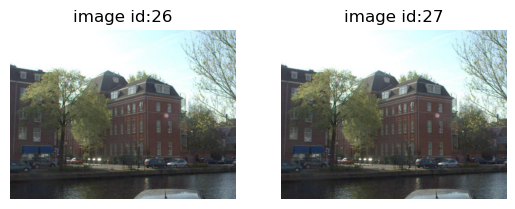

[31]
29 28
/scratch/mzaffar/olaf/datasets_vg/datasets/amstertime_better/images/test/database/@0@1024001@@@@@1361@@@@@@@@.jpg
/scratch/mzaffar/olaf/datasets_vg/datasets/amstertime_better/images/test/database/@0@1024000@@@@@1024@@@@@@@@.jpg
/scratch/mzaffar/olaf/datasets_vg/datasets/amstertime_better/images/test/database/@0@1024002@@@@@1361@@@@@@@@.jpg


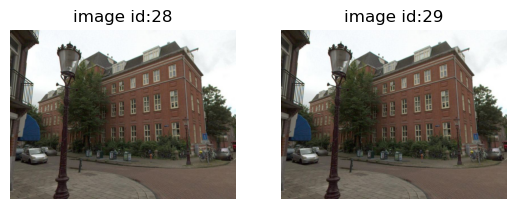

[88]
85 84
/scratch/mzaffar/olaf/datasets_vg/datasets/amstertime_better/images/test/database/@0@1077001@@@@@1353@@@@@@@@.jpg
/scratch/mzaffar/olaf/datasets_vg/datasets/amstertime_better/images/test/database/@0@1077000@@@@@1077@@@@@@@@.jpg
/scratch/mzaffar/olaf/datasets_vg/datasets/amstertime_better/images/test/database/@0@1077002@@@@@1353@@@@@@@@.jpg


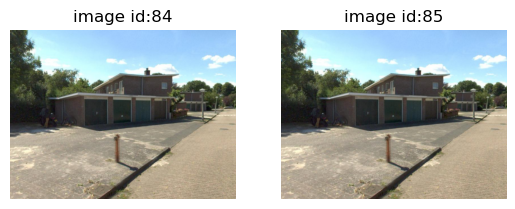

[277]
274 273
/scratch/mzaffar/olaf/datasets_vg/datasets/amstertime_better/images/test/database/@0@1255001@@@@@1256@@@@@@@@.jpg
/scratch/mzaffar/olaf/datasets_vg/datasets/amstertime_better/images/test/database/@0@1255000@@@@@1255@@@@@@@@.jpg
/scratch/mzaffar/olaf/datasets_vg/datasets/amstertime_better/images/test/database/@0@1255002@@@@@1256@@@@@@@@.jpg


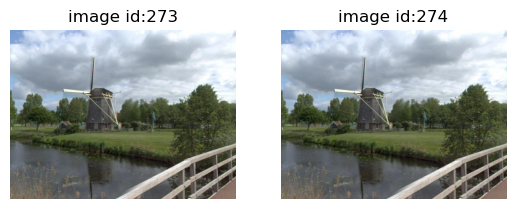

[326]
322 321
/scratch/mzaffar/olaf/datasets_vg/datasets/amstertime_better/images/test/database/@0@13001@@@@@0014@@@@@@@@.jpg
/scratch/mzaffar/olaf/datasets_vg/datasets/amstertime_better/images/test/database/@0@13000@@@@@0013@@@@@@@@.jpg
/scratch/mzaffar/olaf/datasets_vg/datasets/amstertime_better/images/test/database/@0@13002@@@@@0014@@@@@@@@.jpg


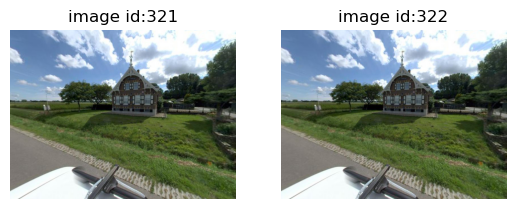

[354]
350 349
/scratch/mzaffar/olaf/datasets_vg/datasets/amstertime_better/images/test/database/@0@1326001@@@@@1327@@@@@@@@.jpg
/scratch/mzaffar/olaf/datasets_vg/datasets/amstertime_better/images/test/database/@0@1326000@@@@@1326@@@@@@@@.jpg
/scratch/mzaffar/olaf/datasets_vg/datasets/amstertime_better/images/test/database/@0@1326002@@@@@1327@@@@@@@@.jpg


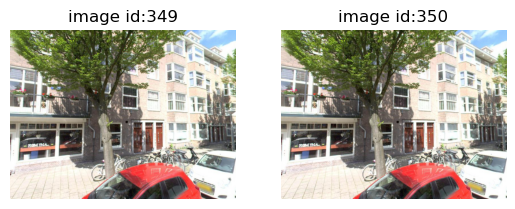

[390]
389 388
/scratch/mzaffar/olaf/datasets_vg/datasets/amstertime_better/images/test/database/@0@1364001@@@@@1365@@@@@@@@.jpg
/scratch/mzaffar/olaf/datasets_vg/datasets/amstertime_better/images/test/database/@0@1364000@@@@@1364@@@@@@@@.jpg
/scratch/mzaffar/olaf/datasets_vg/datasets/amstertime_better/images/test/database/@0@1364002@@@@@1365@@@@@@@@.jpg


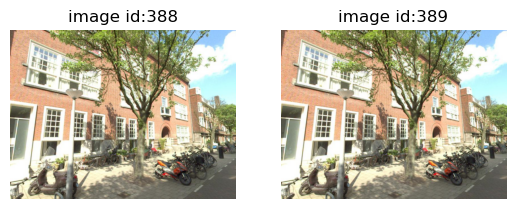

[527]
526 525
/scratch/mzaffar/olaf/datasets_vg/datasets/amstertime_better/images/test/database/@0@276001@@@@@0287@@@@@@@@.jpg
/scratch/mzaffar/olaf/datasets_vg/datasets/amstertime_better/images/test/database/@0@276000@@@@@0276@@@@@@@@.jpg
/scratch/mzaffar/olaf/datasets_vg/datasets/amstertime_better/images/test/database/@0@276002@@@@@0287@@@@@@@@.jpg


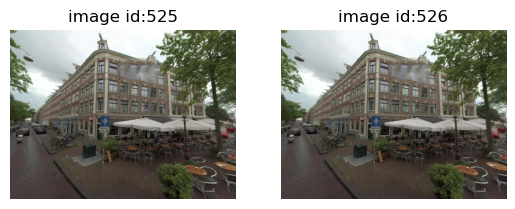

[613]
612 611
/scratch/mzaffar/olaf/datasets_vg/datasets/amstertime_better/images/test/database/@0@360001@@@@@0006@@@@@@@@.jpg
/scratch/mzaffar/olaf/datasets_vg/datasets/amstertime_better/images/test/database/@0@360000@@@@@0360@@@@@@@@.jpg
/scratch/mzaffar/olaf/datasets_vg/datasets/amstertime_better/images/test/database/@0@360002@@@@@0006@@@@@@@@.jpg


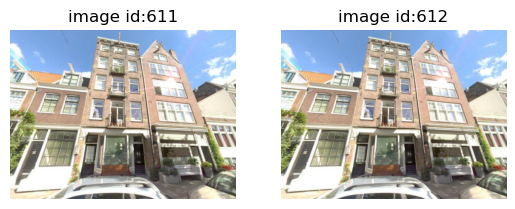

[666]
664 663
/scratch/mzaffar/olaf/datasets_vg/datasets/amstertime_better/images/test/database/@0@416001@@@@@0500@@@@@@@@.jpg
/scratch/mzaffar/olaf/datasets_vg/datasets/amstertime_better/images/test/database/@0@416000@@@@@0416@@@@@@@@.jpg
/scratch/mzaffar/olaf/datasets_vg/datasets/amstertime_better/images/test/database/@0@416002@@@@@0500@@@@@@@@.jpg


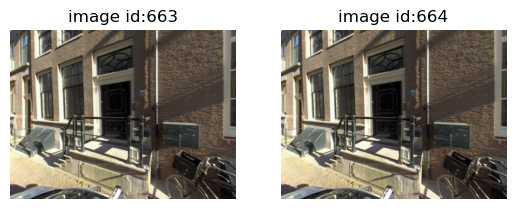

[690]
688 687
/scratch/mzaffar/olaf/datasets_vg/datasets/amstertime_better/images/test/database/@0@441001@@@@@0443@@@@@@@@.jpg
/scratch/mzaffar/olaf/datasets_vg/datasets/amstertime_better/images/test/database/@0@441000@@@@@0441@@@@@@@@.jpg
/scratch/mzaffar/olaf/datasets_vg/datasets/amstertime_better/images/test/database/@0@441002@@@@@0443@@@@@@@@.jpg


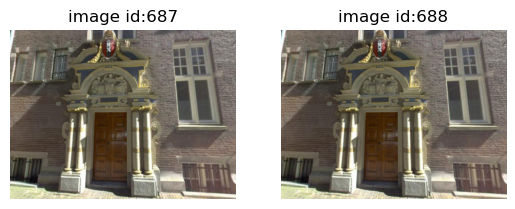

[716]
714 713
/scratch/mzaffar/olaf/datasets_vg/datasets/amstertime_better/images/test/database/@0@471001@@@@@0472@@@@@@@@.jpg
/scratch/mzaffar/olaf/datasets_vg/datasets/amstertime_better/images/test/database/@0@471000@@@@@0471@@@@@@@@.jpg
/scratch/mzaffar/olaf/datasets_vg/datasets/amstertime_better/images/test/database/@0@471002@@@@@0472@@@@@@@@.jpg


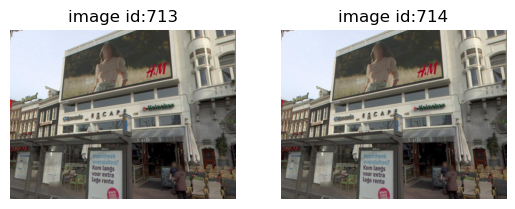

[748]
747 746
/scratch/mzaffar/olaf/datasets_vg/datasets/amstertime_better/images/test/database/@0@508001@@@@@0509@@@@@@@@.jpg
/scratch/mzaffar/olaf/datasets_vg/datasets/amstertime_better/images/test/database/@0@508000@@@@@0508@@@@@@@@.jpg
/scratch/mzaffar/olaf/datasets_vg/datasets/amstertime_better/images/test/database/@0@508002@@@@@0509@@@@@@@@.jpg


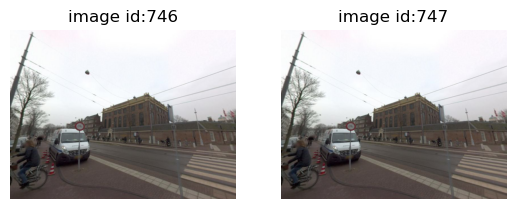

[850]
849 848
/scratch/mzaffar/olaf/datasets_vg/datasets/amstertime_better/images/test/database/@0@616001@@@@@0618@@@@@@@@.jpg
/scratch/mzaffar/olaf/datasets_vg/datasets/amstertime_better/images/test/database/@0@616000@@@@@0616@@@@@@@@.jpg
/scratch/mzaffar/olaf/datasets_vg/datasets/amstertime_better/images/test/database/@0@616002@@@@@0618@@@@@@@@.jpg


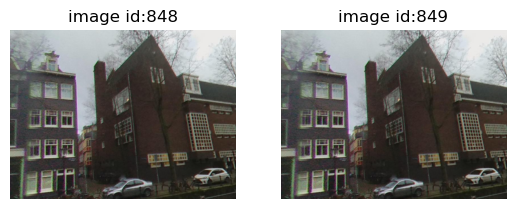

[862]
861 860
/scratch/mzaffar/olaf/datasets_vg/datasets/amstertime_better/images/test/database/@0@627001@@@@@0634@@@@@@@@.jpg
/scratch/mzaffar/olaf/datasets_vg/datasets/amstertime_better/images/test/database/@0@627000@@@@@0627@@@@@@@@.jpg
/scratch/mzaffar/olaf/datasets_vg/datasets/amstertime_better/images/test/database/@0@627002@@@@@0634@@@@@@@@.jpg


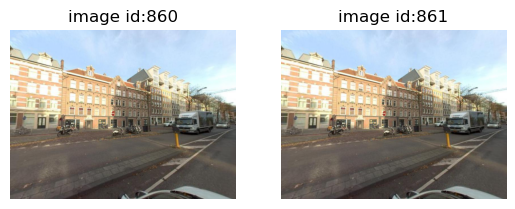

[]
866 865
/scratch/mzaffar/olaf/datasets_vg/datasets/amstertime_better/images/test/database/@0@632001@@@@@0633@@@@@@@@.jpg
/scratch/mzaffar/olaf/datasets_vg/datasets/amstertime_better/images/test/database/@0@632000@@@@@0632@@@@@@@@.jpg
/scratch/mzaffar/olaf/datasets_vg/datasets/amstertime_better/images/test/database/@0@632002@@@@@0633@@@@@@@@.jpg


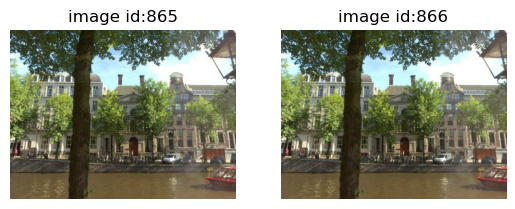

[964]
963 962
/scratch/mzaffar/olaf/datasets_vg/datasets/amstertime_better/images/test/database/@0@725001@@@@@0728@@@@@@@@.jpg
/scratch/mzaffar/olaf/datasets_vg/datasets/amstertime_better/images/test/database/@0@725000@@@@@0725@@@@@@@@.jpg
/scratch/mzaffar/olaf/datasets_vg/datasets/amstertime_better/images/test/database/@0@725002@@@@@0728@@@@@@@@.jpg


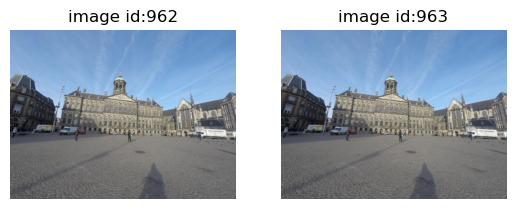

[980]
979 978
/scratch/mzaffar/olaf/datasets_vg/datasets/amstertime_better/images/test/database/@0@740001@@@@@0773@@@@@@@@.jpg
/scratch/mzaffar/olaf/datasets_vg/datasets/amstertime_better/images/test/database/@0@740000@@@@@0740@@@@@@@@.jpg
/scratch/mzaffar/olaf/datasets_vg/datasets/amstertime_better/images/test/database/@0@740002@@@@@0773@@@@@@@@.jpg


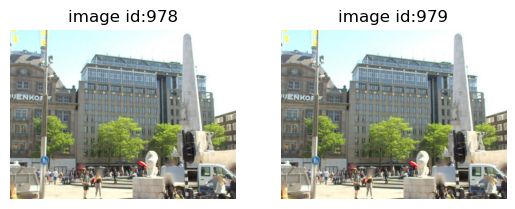

[984]
982 981
/scratch/mzaffar/olaf/datasets_vg/datasets/amstertime_better/images/test/database/@0@742001@@@@@0777@@@@@@@@.jpg
/scratch/mzaffar/olaf/datasets_vg/datasets/amstertime_better/images/test/database/@0@742000@@@@@0742@@@@@@@@.jpg
/scratch/mzaffar/olaf/datasets_vg/datasets/amstertime_better/images/test/database/@0@742002@@@@@0777@@@@@@@@.jpg


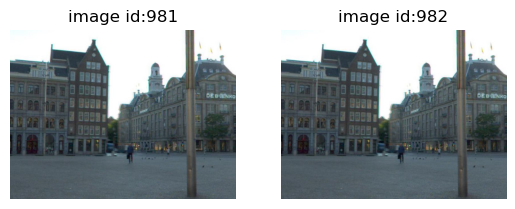

[]
1010 1009
/scratch/mzaffar/olaf/datasets_vg/datasets/amstertime_better/images/test/database/@0@771001@@@@@0774@@@@@@@@.jpg
/scratch/mzaffar/olaf/datasets_vg/datasets/amstertime_better/images/test/database/@0@771000@@@@@0771@@@@@@@@.jpg
/scratch/mzaffar/olaf/datasets_vg/datasets/amstertime_better/images/test/database/@0@771002@@@@@0774@@@@@@@@.jpg


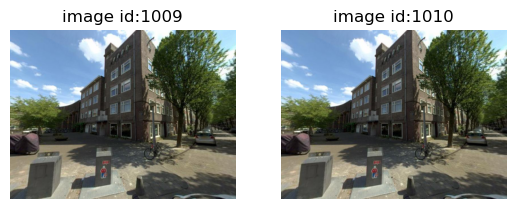

[1013]
1012 1011
/scratch/mzaffar/olaf/datasets_vg/datasets/amstertime_better/images/test/database/@0@772001@@@@@0775@@@@@@@@.jpg
/scratch/mzaffar/olaf/datasets_vg/datasets/amstertime_better/images/test/database/@0@772000@@@@@0772@@@@@@@@.jpg
/scratch/mzaffar/olaf/datasets_vg/datasets/amstertime_better/images/test/database/@0@772002@@@@@0775@@@@@@@@.jpg


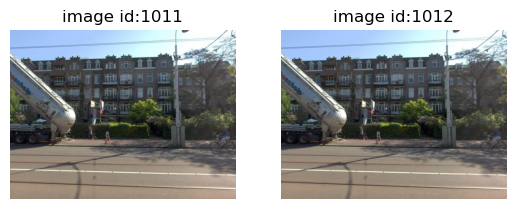

[1020]
1019 1018
/scratch/mzaffar/olaf/datasets_vg/datasets/amstertime_better/images/test/database/@0@784001@@@@@0788@@@@@@@@.jpg
/scratch/mzaffar/olaf/datasets_vg/datasets/amstertime_better/images/test/database/@0@784000@@@@@0784@@@@@@@@.jpg
/scratch/mzaffar/olaf/datasets_vg/datasets/amstertime_better/images/test/database/@0@784002@@@@@0788@@@@@@@@.jpg


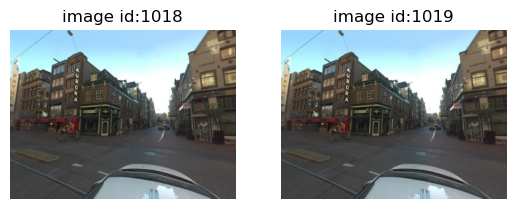

[1023]
1022 1021
/scratch/mzaffar/olaf/datasets_vg/datasets/amstertime_better/images/test/database/@0@786001@@@@@0793@@@@@@@@.jpg
/scratch/mzaffar/olaf/datasets_vg/datasets/amstertime_better/images/test/database/@0@786000@@@@@0786@@@@@@@@.jpg
/scratch/mzaffar/olaf/datasets_vg/datasets/amstertime_better/images/test/database/@0@786002@@@@@0793@@@@@@@@.jpg


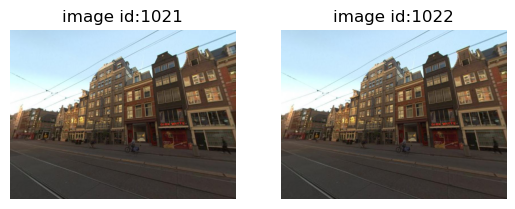

[]
1026 1025
/scratch/mzaffar/olaf/datasets_vg/datasets/amstertime_better/images/test/database/@0@792001@@@@@0794@@@@@@@@.jpg
/scratch/mzaffar/olaf/datasets_vg/datasets/amstertime_better/images/test/database/@0@792000@@@@@0792@@@@@@@@.jpg
/scratch/mzaffar/olaf/datasets_vg/datasets/amstertime_better/images/test/database/@0@792002@@@@@0794@@@@@@@@.jpg


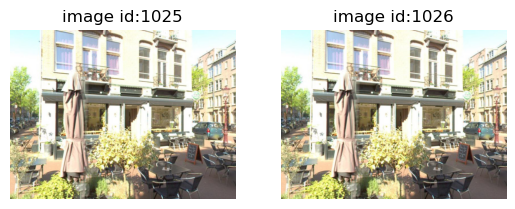

[]
1027 1025
/scratch/mzaffar/olaf/datasets_vg/datasets/amstertime_better/images/test/database/@0@792001@@@@@0795@@@@@@@@.jpg
/scratch/mzaffar/olaf/datasets_vg/datasets/amstertime_better/images/test/database/@0@792000@@@@@0792@@@@@@@@.jpg
/scratch/mzaffar/olaf/datasets_vg/datasets/amstertime_better/images/test/database/@0@792002@@@@@0795@@@@@@@@.jpg


FileNotFoundError: [Errno 2] No such file or directory: '/scratch/mzaffar/olaf/datasets_vg/datasets/amstertime_better/images/test/queries/@0@793000@@@@@0793@@@@@@@@.jpg'

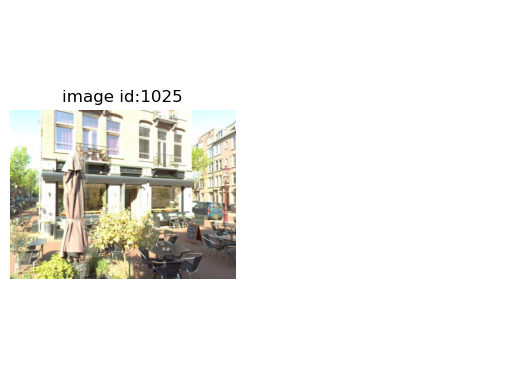

In [18]:
u=0
double_databases=[]
double_queries=[]
for i,feature in enumerate(database_features):
    x=np.argwhere((database_features == feature).all(axis=1))[0]
    x=x[x!=i]
    
    if len(x)>0:
        print(eval_ds.soft_positives_per_query[i])
#         print([eval_ds.database_paths[pths] for pths in eval_ds.soft_positives_per_query[i]])
        for im_id in x:
            if im_id not in double_databases and im_id not in eval_ds.soft_positives_per_query[i]:
                print(i,im_id)
        #         print(eval_ds.database_utms[i])
        #         print(eval_ds.database_paths[i].split("/")[-1])
                double_databases.append(i)
                double_queries.append(eval_ds.database_paths[i].split("/")[-1])

                fig,[ax1,ax2]=plt.subplots(1,2)
                ax1.axis("off")
                ax2.axis("off")

            #     print(im_idx[0])
        #         print(eval_ds.database_paths[i].split('/')[-1])

                ax1.set_title(f"image id:{im_id}")
                ax1.imshow(path_to_pil_img(eval_ds.database_paths[im_id]))
                
                new_name=eval_ds.database_paths[i]
                new_name_query=eval_ds.queries_paths[i]

        #         print(eval_ds.queries_paths[i])
                new_name=new_name.split("@")
                new_location=eval_ds.database_paths[im_id].split("@")[2]
                new_name[2]=str(int(new_location)+1)
                new_name="@".join(new_name)
                
                while True:
                    if os.path.exists(new_name):
                        new_name=new_name.split("@")
                        new_name[2]=str(int(new_name[2])+1)
                        new_name="@".join(new_name)
                    else:
                        break
                    
                 
                print(eval_ds.database_paths[i])
                print(eval_ds.database_paths[im_id])
                print(new_name)
                shutil.move(eval_ds.database_paths[i],new_name)
                eval_ds.database_paths[i]=new_name

                new_name_query=new_name_query.split("@")
                new_name_query[2]=str(int(new_location)+1)
                new_name_query="@".join(new_name_query)
                while True:
                    if os.path.exists(new_name_query):
                        new_name_query=new_name_query.split("@")
                        new_name_query[2]=str(int(new_name_query[2])+1)
                        new_name_query="@".join(new_name_query)
                    else:
                        break
                        
                shutil.move(eval_ds.queries_paths[im_id],new_name_query)
                eval_ds.queries_paths[i]=new_name_query


        #         print(eval_ds.database_paths[i])
        #         print(eval_ds.queries_paths[i])
                ax2.set_title(f"image id:{i}")
                ax2.imshow(path_to_pil_img(eval_ds.database_paths[i]))
                plt.show()
                u+=1

#     if u>20:
#         break
# for i, feature in enumerate(queries_features):
#     if len(np.where((database_features == feature).all(axis=1))[0])>1:
#         double_queries.append(i)
# print(double_databases,double_queries)
print(u)
u=0
double_databases=[]
double_queries=[]
for i,feature in enumerate(queries_features):
    x=np.where((queries_features == feature).all(axis=1))[0]
    x=x[x!=i]
    if len(x)>0 and x[0] not in double_databases:
#         print(eval_ds.database_utms[i])
#         print(eval_ds.database_paths[i].split("/")[-1])
        double_databases.append(i)
#         double_queries.append(eval_ds.database_paths[i].split("/")[-1])
        
#         fig,[ax1,ax2]=plt.subplots(1,2)
#         ax1.axis("off")
#         ax2.axis("off")
        
#     #     print(im_idx[0])
# #         print(eval_ds.database_paths[i].split('/')[-1])
        
#         ax1.set_title(f"image id:{x[0]}")
#         ax1.imshow(path_to_pil_img(eval_ds.database_paths[x[0]]))
        
#         ax2.set_title(f"image id:{i}")
#         ax2.imshow(path_to_pil_img(eval_ds.database_paths[i]))
#         plt.show()
        u+=1
#     if u>20:
#         break
# for i, feature in enumerate(queries_features):
#     if len(np.where((database_features == feature).all(axis=1))[0])>1:
#         double_queries.append(i)
# print(double_databases,double_queries)
print(u)

In [ ]:
new_name_copy=new_name

datatype=new_name_copy.split(".")[-1]

new_name=new_name.split("@")
new_name[2]=str(int(new_name[2])+5)
new_name="@".join(new_name)
move(eval_ds.database_paths[i],new_name)
eval_ds.database_paths[i]=new_name

new_name_query=new_name_query.split("@")
new_name_query[2]=str(int(new_name_query[2])+5)
new_name_query="@".join(new_name_query)
move(eval_ds.queries_paths[i],new_name_query)
eval_ds.queries_paths[i]=new_name_query

print(new_name_copy)
        print(eval_ds.database_paths[i])
        print(eval_ds.queries_paths[i])
print(new_name)